<a href="https://colab.research.google.com/github/eaus2006/Proyecto_Final_Bussines_Analytics/blob/main/BA_Grupo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Analítica de Negocios: Kuska Perú Travel - Identificación de Destinos Subposicionados

## Bloque 1: Carga, Concatenación y Estandarización de Datos MINCETUR

Este bloque se encarga de la carga de todos los archivos CSV de MINCETUR, su concatenación en un único DataFrame (`df_mincetur`), y una fase inicial de estandarización y limpieza. Esto incluye la normalización de los nombres de las columnas, la conversión de tipos de datos a un formato adecuado y la estandarización de los nombres de los departamentos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Definir la ruta base a la carpeta de Google Drive donde se encuentran los datasets
base_path = '/content/drive/MyDrive/Proyecto_BA_grupo_1/'

# Lista de archivos CSV de MINCETUR
mincetur_files = [
    'Indicadores_ocupabilidad_2019.csv',
    'Indicadores_ocupabilidad_2020.csv',
    'Indicadores_ocupabilidad_2021.csv',
    'Indicadores_ocupabilidad_2022.csv',
    'Indicadores_ocupabilidad_2023.csv',
    'Indicadores_ocupabilidad_2024.csv',
    'Indicadores_ocupabilidad_2025_1er_semestre.csv'
]

import pandas as pd
import unicodedata
import re

# Función para estandarizar nombres de columnas (reutilizada y optimizada)
def standardize_column_names(df):
    cols = df.columns
    new_cols = []
    name_mapping = {
        'anio': 'anio', 'ano': 'anio',
        'mes': 'mes',
        'clase': 'clase', 'descripcion clase': 'descripcion_clase',
        'categoria': 'categoria', 'descripcion categoria': 'descripcion_categoria',
        'departamento': 'departamento',
        'ubigeo': 'ubigeo',
        'numero de establecimiento': 'numero_establecimientos', 'numero_establecimientos': 'numero_establecimientos',
        'numero de habitaciones': 'numero_habitaciones', 'numero_habitaciones': 'numero_habitaciones',
        'numero de plazas-cama': 'numero_plazas_cama', 'numero plazas cama': 'numero_plazas_cama', 'numero_plazas_cama': 'numero_plazas_cama', 'numero_de_plazas_cama': 'numero_plazas_cama',
        'tnoh en el mes': 'porcentaje_tnoh', 'porcentaje_tnoh': 'porcentaje_tnoh',
        'tnoc en el mes': 'porcentaje_tnoc', 'porcentaje_tnoc': 'porcentaje_tnoc',
        'prom permanencia dias': 'promedio_permanencia', 'promedio_permanencia': 'promedio_permanencia',
        'prom permanencia - nac dias': 'promedio_permanencia_nac', 'prom permanencia nac dias': 'promedio_permanencia_nac', 'promedio_permanencia_nac': 'promedio_permanencia_nac',
        'prom permanencia - ext dias': 'promedio_permanencia_ext', 'prom permanencia ext dias': 'promedio_permanencia_ext', 'promedio_permanencia_ext': 'promedio_permanencia_ext',
        'total de arribos en el mes': 'total_arribos', 'total_arribos': 'total_arribos',
        'total de arribos mes - nac': 'total_arribos_nac', 'total de arribos mes nac': 'total_arribos_nac', 'total_arribos_nac': 'total_arribos_nac',
        'total de arribos mes - ext': 'total_arribos_ext', 'total de arribos mes ext': 'total_arribos_ext', 'total_arribos_ext': 'total_arribos_ext',
        'total pernoct mes': 'total_pernoct', 'total_pernoct': 'total_pernoct',
        'total pernoct mes - nac dias': 'total_pernoct_nac', 'total pernoct mes nac dias': 'total_pernoct_nac', 'total_pernoct_nac': 'total_pernoct_nac',
        'total pernoct mes - ext dias': 'total_pernoct_ext', 'total pernoct mes ext dias': 'total_pernoct_ext', 'total_pernoct_ext': 'total_pernoct_ext',
        'total empleo en el mes': 'total_empleo', 'total_empleo': 'total_empleo',
        'fecha_corte': 'fecha_corte',
        'id_clase': 'id_clase',
        'id_categoria': 'id_categoria',
        'id_ubigeo': 'id_ubigeo',
    }

    for col in cols:
        processed_col = col.lower()
        processed_col = unicodedata.normalize('NFKD', processed_col).encode('ascii', 'ignore').decode('utf-8')
        processed_col = re.sub(r'[^a-z0-9\s]+', ' ', processed_col).strip()
        processed_col = re.sub(r'\s+', ' ', processed_col)

        if processed_col in name_mapping:
            new_cols.append(name_mapping[processed_col])
        else:
            new_cols.append(processed_col.replace(' ', '_'))

    df.columns = new_cols
    return df

# Función para estandarizar nombres de departamentos
def standardize_department_name(df, column_name):
    df[column_name] = df[column_name].str.upper() # Convertir a mayúsculas
    df[column_name] = df[column_name].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8') # Eliminar tildes
    df[column_name] = df[column_name].str.replace(r'[^A-Z\s]', '', regex=True) # Eliminar caracteres no alfabéticos (excepto espacios)
    df[column_name] = df[column_name].str.strip() # Eliminar espacios en blanco alrededor
    return df

# Lista para almacenar DataFrames individuales
df_list = []

# Cargar y concatenar cada archivo CSV
for file in mincetur_files:
    file_path = base_path + file
    try:
        df = pd.read_csv(file_path, encoding='latin1', sep=';', decimal=',')
        df = standardize_column_names(df)
        df_list.append(df)
        print(f"Cargado y columnas estandarizadas: {file}")
    except FileNotFoundError:
        print(f"Error: El archivo {file} no fue encontrado en {file_path}")
    except Exception as e:
        print(f"Error al cargar {file}: {e}")

# Concatenar todos los DataFrames
if df_list:
    df_mincetur = pd.concat(df_list, ignore_index=True)
    print("\nTodos los archivos MINCETUR han sido cargados y concatenados.")
else:
    print("\nNo se pudo cargar ningún archivo. df_mincetur no ha sido creado.")

# Estandarizar nombres de departamentos
if 'departamento' in df_mincetur.columns:
    df_mincetur = standardize_department_name(df_mincetur, 'departamento')
    print("Nombres de departamentos estandarizados.")

# Conversión de tipos de datos y manejo de valores numéricos
numeric_cols_to_convert = [
    'anio', 'mes', 'numero_establecimientos', 'numero_habitaciones', 'numero_plazas_cama',
    'porcentaje_tnoh', 'porcentaje_tnoc', 'promedio_permanencia', 'promedio_permanencia_nac',
    'promedio_permanencia_ext', 'total_arribos', 'total_arribos_nac', 'total_arribos_ext',
    'total_pernoct', 'total_pernoct_nac', 'total_pernoct_ext', 'total_empleo'
]

for col in numeric_cols_to_convert:
    if col in df_mincetur.columns:
        if col in ['anio', 'mes']:
            df_mincetur[col] = pd.to_numeric(df_mincetur[col], errors='coerce').astype('Int64')
        else:
            df_mincetur[col] = pd.to_numeric(df_mincetur[col], errors='coerce')
            # Clip percentage columns to 100
            if col in ['porcentaje_tnoh', 'porcentaje_tnoc']:
                df_mincetur[col] = df_mincetur[col].clip(upper=100.0)

# Imputar nulos en columnas numéricas clave con la mediana (excluyendo 'numero_plazas_cama' si ya está limpio)
# Columna 'numero_plazas_cama' se excluye por su tratamiento específico en el contexto original (sin NaNs)
numeric_cols_for_median_fill = [
    'numero_establecimientos', 'numero_habitaciones', 'total_arribos',
    'total_arribos_nac', 'total_arribos_ext', 'total_pernoct',
    'porcentaje_tnoh', 'porcentaje_tnoc', 'promedio_permanencia',
    'promedio_permanencia_nac', 'promedio_permanencia_ext', 'total_empleo'
]

for col in numeric_cols_for_median_fill:
    if col in df_mincetur.columns and df_mincetur[col].isnull().any():
        median_val = df_mincetur[col].median()
        df_mincetur[col] = df_mincetur[col].fillna(median_val)
        print(f"Columna '{col}': nulos rellenados con la mediana ({median_val}).")

print("\n--- Primeras 5 filas del DataFrame consolidado (df_mincetur) ---")
display(df_mincetur.head())
print("\n--- Información general del DataFrame consolidado ---")
df_mincetur.info()
print("\n--- Valores únicos de DEPARTAMENTO después de estandarizar ---")
print(df_mincetur['departamento'].unique())

Error: El archivo Indicadores_ocupabilidad_2019.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2019.csv
Error: El archivo Indicadores_ocupabilidad_2020.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2020.csv
Error: El archivo Indicadores_ocupabilidad_2021.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2021.csv
Error: El archivo Indicadores_ocupabilidad_2022.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2022.csv
Error: El archivo Indicadores_ocupabilidad_2023.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2023.csv
Error: El archivo Indicadores_ocupabilidad_2024.csv no fue encontrado en /content/drive/MyDrive/Proyecto_BA_grupo_1/Indicadores_ocupabilidad_2024.csv
Error: El archivo Indicadores_ocupabilidad_2025_1er_semestre.csv no fue encontrado en /content/drive

NameError: name 'df_mincetur' is not defined

## Bloque 2: Diagnóstico de Calidad y Salud de Datos

Esta sección proporciona un resumen exhaustivo del estado actual de los datos. Incluye una tabla de diagnóstico de calidad con tipos de datos, recuentos de valores nulos y ceros, y estadísticas descriptivas clave para cada columna. Además, se presenta un resumen estadístico de las variables numéricas clave para identificar distribuciones y posibles valores atípicos.

In [ ]:
data_quality_report = []

for col in df_mincetur.columns:
    dtype = df_mincetur[col].dtype
    total_nans = df_mincetur[col].isnull().sum()
    percent_nans = (total_nans / len(df_mincetur)) * 100
    total_zeros = (df_mincetur[col] == 0).sum() if pd.api.types.is_numeric_dtype(df_mincetur[col]) else 0

    min_val = None
    max_val = None
    median_val = None

    if pd.api.types.is_numeric_dtype(df_mincetur[col]):
        try:
            min_val = df_mincetur[col].min()
            max_val = df_mincetur[col].max()
            median_val = df_mincetur[col].median()
        except TypeError: # Handle cases where min/max might fail for mixed types after coerce
            pass

    data_quality_report.append({
        'Columna': col,
        'Tipo de Dato': dtype,
        'Total NaNs': total_nans,
        '% NaNs': round(percent_nans, 2),
        'Total Ceros': total_zeros,
        'Min': min_val,
        'Max': max_val,
        'Mediana': median_val
    })

df_quality_report = pd.DataFrame(data_quality_report)

print("\n--- Tabla de Diagnóstico de Calidad y Salud de Datos ---")
display(df_quality_report)

print("\n--- Resumen Estadístico de Variables Numéricas Clave ---")
numeric_vars_summary = [
    'numero_establecimientos', 'numero_habitaciones', 'numero_plazas_cama',
    'total_arribos', 'total_arribos_nac', 'total_arribos_ext',
    'total_pernoct', 'porcentaje_tnoh', 'porcentaje_tnoc', 'promedio_permanencia'
]
display(df_mincetur[[
    col for col in numeric_vars_summary if col in df_mincetur.columns
]].describe())

print("\n--- Identificación de posibles Outliers (valores mínimos y máximos extremos) ---")
print("Basado en el resumen estadístico (min/max):\n")
print("- **numero_establecimientos, numero_habitaciones, numero_plazas_cama:** Los valores máximos son significativamente altos en comparación con la media y la mediana, sugiriendo la presencia de algunos establecimientos muy grandes.")
print("- **total_arribos, total_arribos_nac, total_arribos_ext, total_pernoct:** Similar a las variables de capacidad, los máximos son muy elevados. Los ceros son frecuentes, lo cual requiere entender si son ausencias reales o datos faltantes.")
print("- **porcentaje_tnoh, porcentaje_tnoc:** Presentan un rango de 0.0 a 100.0, lo cual es esperado para un porcentaje. El clip a 100.0 asegura que no haya valores atípicos superiores. Un 0% constante en muchos registros podría indicar inactividad o errores en la recolección.")
print("- **promedio_permanencia:** El valor máximo es bastante alto, mientras que el 75% de los datos es significativamente menor. Esto sugiere algunos casos con estancias prolongadas que podrían ser atípicos o patrones de negocio específicos.")


--- Tabla de Diagnóstico de Calidad y Salud de Datos ---


,Columna,Tipo de Dato,Total NaNs,% NaNs,Total Ceros,Min,Max,Mediana
0,anio,Int64,0,0.0,0,2019.0,2025.00,2022.00
1,mes,Int64,0,0.0,0,1.0,12.00,6.00
2,clase,object,0,0.0,0,NaN,NaN,NaN
3,descripcion_clase,object,9219,23.8,0,NaN,NaN,NaN
4,categoria,object,0,0.0,0,NaN,NaN,NaN
5,descripcion_categoria,object,9219,23.8,0,NaN,NaN,NaN
6,departamento,object,0,0.0,0,NaN,NaN,NaN
7,ubigeo,float64,9219,23.8,0,10000.0,250000.00,130000.00
8,numero_establecimientos,int64,0,0.0,0,1.0,7949.00,17.00
9,numero_habitaciones,int64,0,0.0,0,1.0,86746.00,439.00



--- Resumen Estadístico de Variables Numéricas Clave ---


,numero_establecimientos,numero_habitaciones,numero_plazas_cama,total_arribos,total_arribos_nac,total_arribos_ext,total_pernoct,porcentaje_tnoh,porcentaje_tnoc,promedio_permanencia
count,38730.000000,38730.000000,9219.000000,3.873000e+04,3.873000e+04,38730.000000,3.873000e+04,38730.000000,38730.000000,38730.000000
mean,194.941286,2432.753834,4467.201649,3.518576e+04,3.184980e+04,3335.960728,4.605772e+04,26.007677,22.022960,1.697723
std,644.596310,6314.355664,11503.233146,2.228515e+05,2.128912e+05,15452.236390,2.674220e+05,16.412182,15.037972,1.769837
min,1.000000,1.000000,8.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,4.000000,123.000000,234.000000,6.670000e+02,5.190000e+02,10.000000,1.187250e+03,16.240000,12.910000,1.170000
50%,17.000000,439.000000,864.000000,3.457500e+03,2.777000e+03,143.000000,5.738000e+03,23.760000,19.500000,1.450000
75%,112.000000,2385.000000,4437.500000,1.657100e+04,1.374400e+04,872.000000,2.409900e+04,33.430000,28.260000,1.850000
max,7949.000000,86746.000000,153470.000000,3.783237e+06,3.539347e+06,384261.000000,5.348792e+06,100.000000,100.000000,55.360000



--- Identificación de posibles Outliers (valores mínimos y máximos extremos) ---
Basado en el resumen estadístico (min/max):

- **numero_establecimientos, numero_habitaciones, numero_plazas_cama:** Los valores máximos son significativamente altos en comparación con la media y la mediana, sugiriendo la presencia de algunos establecimientos muy grandes.
- **total_arribos, total_arribos_nac, total_arribos_ext, total_pernoct:** Similar a las variables de capacidad, los máximos son muy elevados. Los ceros son frecuentes, lo cual requiere entender si son ausencias reales o datos faltantes.
- **porcentaje_tnoh, porcentaje_tnoc:** Presentan un rango de 0.0 a 100.0, lo cual es esperado para un porcentaje. El clip a 100.0 asegura que no haya valores atípicos superiores. Un 0% constante en muchos registros podría indicar inactividad o errores en la recolección.
- **promedio_permanencia:** El valor máximo es bastante alto, mientras que el 75% de los datos es significativamente menor. Esto sugiere

## Bloque 3: Tablas Consolidadas de Negocio para Kuska Perú Travel

En este bloque, se generarán tablas consolidadas clave para el objetivo de negocio de Kuska. Estas tablas facilitarán la identificación de destinos subposicionados y la comprensión de patrones de demanda:

*   **Tabla de Perfil de Oferta vs. Demanda por Departamento:** Para identificar regiones con alta capacidad y bajo flujo de visitantes.
*   **Matriz de Estacionalidad Tabular (Desglose Mensual):** Para entender los patrones de demanda a lo largo del año.
*   **Matriz de Composición de Visitantes (Nacionales vs. Extranjeros):** Para comprender la procedencia de los turistas y adaptar estrategias de marketing.

### 3.1. Tabla de Perfil de Oferta vs. Demanda por Departamento

In [ ]:
# Calcular promedios mensuales por departamento para las métricas clave
offer_demand_profile = df_mincetur.groupby('departamento').agg(
    promedio_habitaciones=('numero_habitaciones', 'mean'),
    promedio_plazas_cama=('numero_plazas_cama', 'mean'),
    promedio_total_arribos=('total_arribos', 'mean'),
    promedio_arribos_nac=('total_arribos_nac', 'mean'),
    promedio_arribos_ext=('total_arribos_ext', 'mean'),
    promedio_porcentaje_tnoh=('porcentaje_tnoh', 'mean'),
    promedio_permanencia=('promedio_permanencia', 'mean')
).reset_index()

# Renombrar columnas para mayor claridad en el display
offer_demand_profile.rename(columns={
    'promedio_habitaciones': 'Habitaciones (Prom. Mensual)',
    'promedio_plazas_cama': 'Plazas Cama (Prom. Mensual)',
    'promedio_total_arribos': 'Arribos Totales (Prom. Mensual)',
    'promedio_arribos_nac': 'Arribos Nacionales (Prom. Mensual)',
    'promedio_arribos_ext': 'Arribos Extranjeros (Prom. Mensual)',
    'promedio_porcentaje_tnoh': '% TNOH (Prom. Mensual)',
    'promedio_permanencia': 'Permanencia (Prom. Mensual, Días)'
}, inplace=True)

# Ordenar la tabla por '% TNOH (Prom. Mensual)' de menor a mayor
offer_demand_profile_sorted = offer_demand_profile.sort_values(by='% TNOH (Prom. Mensual)', ascending=True).reset_index(drop=True)

print("\n--- Tabla Consolidada de Perfil de Oferta vs. Demanda por Departamento (Ordenada por % TNOH) ---")
display(offer_demand_profile_sorted)


--- Tabla Consolidada de Perfil de Oferta vs. Demanda por Departamento (Ordenada por % TNOH) ---


,departamento,Habitaciones (Prom. Mensual),Plazas Cama (Prom. Mensual),Arribos Totales (Prom. Mensual),Arribos Nacionales (Prom. Mensual),Arribos Extranjeros (Prom. Mensual),% TNOH (Prom. Mensual),"Permanencia (Prom. Mensual, Días)"
0,CAJAMARCA,2504.088440,4337.436693,13013.704359,12825.310171,188.394820,17.004788,1.259735
1,AYACUCHO,1531.718799,2491.728395,8256.480253,8117.308057,139.172196,17.284218,1.634092
2,AMAZONAS,1162.291793,2007.716049,7779.319149,7507.957447,271.361702,19.727690,1.109301
3,HUANCAVELICA,681.539027,1109.749104,4024.701561,4009.300275,15.401286,19.992443,1.313811
4,ANCASH,2362.075325,4533.388889,18453.319481,17763.540260,689.779221,20.542968,1.516844
5,TACNA,1453.667930,2963.895425,7834.747536,5138.520091,2696.227445,21.197096,1.856126
6,PASCO,951.017682,1884.788889,6138.297315,6111.821873,26.475442,21.410923,1.343163
7,JUNIN,3281.402667,5993.811111,21997.109333,21871.221333,125.888000,23.093500,1.601447
8,UCAYALI,1291.135501,2225.403509,6271.027100,6027.913279,243.119241,23.198428,2.475169
9,PUNO,1846.458606,3630.484848,14707.282906,12065.679571,2641.603335,23.890756,1.497570


**Interpretación de Negocio para Kuska Perú Travel - Identificación de Regiones Subposicionadas:**
Para Kuska, la prioridad de inversión debe centrarse en regiones con baja Tasa Neta de Ocupación Hotelera (% TNOH) pero con una oferta de habitaciones y camas capaz de recibir mayor flujo, como Cajamarca, Ayacucho, Amazonas y Huancavelica. La combinación de una baja ocupación, pocos arribos y una permanencia promedio corta confirma una clara subutilización de la infraestructura existente. Dirigir los esfuerzos promocionales hacia estos destinos subposicionados permitirá reactivar su demanda turística y optimizar la capacidad hotelera que hoy no se está aprovechando.

### 3.2. Matriz de Estacionalidad Tabular (Desglose Mensual)

In [ ]:
# Crear una tabla pivote para la estacionalidad mensual por departamento
seasonality_pivot = pd.pivot_table(
    df_mincetur,
    values='porcentaje_tnoh',
    index='departamento',
    columns='mes',
    aggfunc='mean'
)

# Renombrar columnas de meses para mayor claridad
seasonality_pivot.columns = [f'Mes {int(col)}' for col in seasonality_pivot.columns]

print("\n--- Matriz de Estacionalidad (Promedio de % TNOH por Departamento y Mes) ---")
display(seasonality_pivot.round(2))

# Identificar los 5 departamentos con menor ocupación general (de la tabla anterior)
under_positioned_regions = offer_demand_profile_sorted.head(5)['departamento'].tolist()

print(f"\n--- Los 3 meses con la menor ocupación (% TNOH) para las regiones potencialmente subposicionadas ({', '.join(under_positioned_regions)}) ---")
for region in under_positioned_regions:
    if region in seasonality_pivot.index:
        lowest_months = seasonality_pivot.loc[region].sort_values(ascending=True).head(3)
        print(f"- {region}: {lowest_months.index.tolist()} (Ocupación: {lowest_months.values.round(2).tolist()}%) ")
    else:
        print(f"- {region}: Datos de estacionalidad no disponibles.")


--- Matriz de Estacionalidad (Promedio de % TNOH por Departamento y Mes) ---


,Mes 1,Mes 2,Mes 3,Mes 4,Mes 5,Mes 6,Mes 7,Mes 8,Mes 9,Mes 10,Mes 11,Mes 12
departamento,,,,,,,,,,,,
AMAZONAS,20.95,21.86,17.14,15.72,17.13,18.48,21.60,23.74,20.96,20.64,20.31,19.33
ANCASH,20.26,20.89,19.10,19.47,20.88,21.06,23.17,20.09,20.62,21.31,20.07,19.88
APURIMAC,26.91,26.50,27.16,27.43,28.06,27.85,29.84,31.36,31.95,30.91,29.83,24.97
AREQUIPA,21.59,22.53,21.50,26.12,29.96,26.54,31.36,34.42,32.04,33.26,29.46,23.15
AYACUCHO,17.14,18.23,15.41,17.43,15.47,15.40,17.80,17.96,18.74,19.32,19.10,16.14
CAJAMARCA,14.65,19.33,15.18,14.49,15.88,16.94,18.94,18.79,18.98,18.16,17.88,15.70
CALLAO,43.28,45.32,41.23,40.37,39.57,42.79,40.89,38.87,42.37,41.18,43.85,42.67
CUSCO,21.96,20.45,24.29,30.93,33.09,32.67,34.69,33.60,33.35,34.22,32.16,25.81
HUANCAVELICA,16.52,18.62,15.76,18.31,20.11,21.54,22.56,21.03,23.49,22.66,22.30,18.42



--- Los 3 meses con la menor ocupación (% TNOH) para las regiones potencialmente subposicionadas (CAJAMARCA, AYACUCHO, AMAZONAS, HUANCAVELICA, ANCASH) ---
- CAJAMARCA: ['Mes 4', 'Mes 1', 'Mes 3'] (Ocupación: [14.49, 14.65, 15.18]%) 
- AYACUCHO: ['Mes 6', 'Mes 3', 'Mes 5'] (Ocupación: [15.4, 15.41, 15.47]%) 
- AMAZONAS: ['Mes 4', 'Mes 5', 'Mes 3'] (Ocupación: [15.72, 17.13, 17.14]%) 
- HUANCAVELICA: ['Mes 3', 'Mes 1', 'Mes 4'] (Ocupación: [15.76, 16.52, 18.31]%) 
- ANCASH: ['Mes 3', 'Mes 4', 'Mes 12'] (Ocupación: [19.1, 19.47, 19.88]%) 



**Hallazgos de Estacionalidad para Kuska Perú Travel:**

La matriz de estacionalidad nos permite ver de manera granular los meses de baja y alta demanda en cada departamento, lo cual es fundamental para planificar campañas de promoción.

*   **Meses de Baja Demanda:** Hemos identificado los 3 meses con menor ocupación para las regiones potencialmente subposicionadas (aquellas con el % TNOH promedio más bajo). Esto resalta oportunidades clave para la inversión promocional.
*   **Identificación de Ventanas de Oportunidad:** Los meses con menor % TNOH representan una 'ventana de oportunidad' para Kuska. Durante estos períodos, la infraestructura hotelera ya está disponible y subutilizada, lo que permite enfocar esfuerzos de marketing para equilibrar la demanda a lo largo del año.
*   **Comparación entre Regiones:** Es importante notar si existen patrones comunes de baja estacionalidad entre los diferentes departamentos o si cada región presenta un comportamiento estacional único, lo cual informaría si una campaña promocional puede ser generalizada o si requiere una adaptación específica por región y mes.

**Recomendación Preliminar:** Utilizar estos hallazgos para diseñar micro-campañas de marketing dirigidas a llenar los 'valles' de demanda en las regiones subposicionadas, promoviendo eventos, paquetes turísticos o descuentos durante los meses identificados con menor ocupación.

### 3.3. Matriz de Composición de Visitantes (Nacionales vs. Extranjeros)

In [ ]:
# Calcular el total de arribos nacionales y extranjeros por departamento
visitor_composition = df_mincetur.groupby('departamento').agg(
    total_arribos_nacionales=('total_arribos_nac', 'sum'),
    total_arribos_extranjeros=('total_arribos_ext', 'sum')
).reset_index()

# Calcular el total global de arribos
visitor_composition['total_arribos'] = visitor_composition['total_arribos_nacionales'] + visitor_composition['total_arribos_extranjeros']

# Calcular los porcentajes
visitor_composition['% Nacionales'] = (visitor_composition['total_arribos_nacionales'] / visitor_composition['total_arribos']) * 100
visitor_composition['% Extranjeros'] = (visitor_composition['total_arribos_extranjeros'] / visitor_composition['total_arribos']) * 100

# Seleccionar y ordenar columnas para la visualización
visitor_composition_final = visitor_composition[['departamento', 'total_arribos_nacionales', 'total_arribos_extranjeros', '% Nacionales', '% Extranjeros']]

# Ordenar por porcentaje de nacionales descendente para ver la dependencia
visitor_composition_final = visitor_composition_final.sort_values(by='% Nacionales', ascending=False).round(2)

print("\n--- Matriz de Composición de Visitantes por Departamento (Nacionales vs. Extranjeros) ---")
display(visitor_composition_final)


--- Matriz de Composición de Visitantes por Departamento (Nacionales vs. Extranjeros) ---


,departamento,total_arribos_nacionales,total_arribos_extranjeros,% Nacionales,% Extranjeros
8,HUANCAVELICA,4366128,16772,99.62,0.38
18,PASCO,9332752,40428,99.57,0.43
11,JUNIN,32806832,188832,99.43,0.57
9,HUANUCO,18419958,123731,99.33,0.67
2,APURIMAC,10028104,127184,98.75,1.25
5,CAJAMARCA,20302466,298229,98.55,1.45
4,AYACUCHO,10276512,176192,98.31,1.69
21,SAN MARTIN,26148872,558688,97.91,2.09
13,LAMBAYEQUE,21924268,589220,97.38,2.62
17,MOQUEGUA,5555828,200284,96.52,3.48


**Análisis de Dependencia de Mercado para Kuska Perú Travel:**

La matriz de composición de visitantes nos ayuda a comprender el perfil del turista que visita cada región, para adaptar las estrategias de promoción y desarrollo de productos turísticos.

*   **Identificación de Mercados Primarios:**
    *   Los departamentos con un `Alto % Nacionales` (parte superior de la tabla) dependen mayormente del turismo interno. Para estas regiones, las estrategias de promoción de Kuska deberían enfocarse en el viajero peruano, destacando la accesibilidad, la cultura local y experiencias de corta duración.
    *   Los departamentos con un `Alto % Extranjeros` (parte inferior de la tabla, con menor % Nacionales) atraen significativamente al turismo internacional. Las campañas para estas regiones deberían centrarse en el posicionamiento global, la oferta de experiencias únicas y de mayor valor añadido, y la colaboración con tour operadores internacionales.

*   **Relevancia para Regiones Subposicionadas:**
    *   Para las **regiones subposicionadas** identificadas anteriormente (baja ocupación), este análisis nos dirá si su problema de demanda es con el mercado nacional, internacional, o ambos. Por ejemplo, si una región subposicionada tiene un `% Nacionales` muy alto, esto sugiere que el mercado interno no está siendo suficiente para llenar su capacidad.
    *   Esto permite a Kuska afinar su estrategia: ¿necesitamos incentivar más el turismo nacional en X región, o hay una oportunidad no explotada para atraer turismo internacional?

**Recomendación Preliminar:** Utilizar esta matriz para segmentar las campañas de marketing. Para las regiones subposicionadas, definir si la prioridad es estimular la demanda interna o desarrollar la oferta para atraer un mayor flujo internacional, basándose en la composición actual de sus visitantes.

# **EDA Enriquecido**

## Bloque 4: Enriquecimiento con Fuente Primaria — Encuesta de Preferencias de Viaje

**Objetivo:** MINCETUR (Bloques 1-3) describe la *oferta* y los *arribos* ya registrados, pero no explica el porqué de la baja demanda. Se incorpora una encuesta primaria ($n = 43$) para medir disposición, interés y barreras hacia destinos menos conocidos.

**Metodología:**
1. Limpieza y renombrado de columnas del formulario.
2. Filtro de calidad usando la pregunta de control de atención (*attention check*).
3. Normalización de variables de respuesta múltiple (regiones, factores, barreras).
4. EDA univariado de variables sociodemográficas y ordinales (Likert).
5. Triangulación: regiones de interés declaradas vs. regiones subposicionadas identificadas en el Bloque 3.

**Limitación:** muestra pequeña ($n=41$ válidas), joven y no probabilística → resultados exploratorios, no generalizables.

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Ruta del archivo de la encuesta (mismo patrón que base_path del Bloque 1)
survey_path = base_path + 'Encuesta.xlsx'
df_encuesta_raw = pd.read_excel(survey_path)

# Renombrar columnas a nombres cortos y manejables
rename_map = {
    'Marca temporal': 'marca_temporal',
    '¿Aceptas participar?  🙋 ': 'acepta_participar',
    '1. 💸 Si dos destinos turísticos ofrecen actividades similares, pero uno es menos conocido y tiene un precio más bajo, ¿Qué tan dispuesto/a estarías a elegir el destino menos conocido?  ': 'disposicion_menos_conocido',
    '2. 🗺️ ¿Qué regiones del Perú considerarías para tu próximo viaje? (máximo 3 opciones)': 'regiones_interes',
    '3. ✨ ¿Qué tan interesado/a estarías en visitar destinos peruanos que actualmente no son de los más turísticos?  ': 'interes_no_turisticos',
    '4. 🎒 ¿Qué factores influyen más en tu elección de un destino turístico? (selecciona hasta 5)': 'factores_eleccion',
    '5. 🚫 ¿Cuáles son las principales razones por las que NO visitarías una región peruana que te interesa? (selecciona hasta 3)': 'razones_no_visitar',
    '6. 🔍 Antes de esta encuesta, ¿Qué tanto conocías sobre la oferta turística de las regiones menos visitadas del Perú?  ': 'conocimiento_previo',
    '7. 🎯 Esta pregunta es para verificar que estás leyendo con atención. Selecciona la opción "Poco importante".  ': 'filtro_atencion',
    '8. 🏨 ¿Qué tan importante es para ti que un destino tenga una buena oferta de alojamiento?  ': 'importancia_alojamiento',
    '9. 💵 ¿Cuánto estarías dispuesto/a a gastar por persona en un viaje turístico nacional de 3-4 días?  ': 'gasto_dispuesto',
    '10. 🎂 Edad  ': 'edad',
    '11. 💼 ¿Actualmente trabajas o realizas prácticas (tienes ingresos propios)?  ': 'trabaja_actualmente',
    '  12. ✈️ ¿Has realizado viajes turísticos dentro del Perú durante los últimos 3 años?  ': 'viajo_ultimos_3_anios',
}
df_encuesta = df_encuesta_raw.rename(columns=rename_map).drop(columns=['acepta_participar'])

# Filtro de calidad: eliminar encuestados que fallaron la pregunta de control de atención (Q7)
n_total = len(df_encuesta)
df_encuesta = df_encuesta[df_encuesta['filtro_atencion'] == 'Poco importante'].drop(columns=['filtro_atencion']).reset_index(drop=True)
n_excluidos = n_total - len(df_encuesta)

print(f"Encuestas totales recolectadas: {n_total}")
print(f"Excluidas por fallar el filtro de atención (Pregunta 7): {n_excluidos}")
print(f"Encuestas válidas para el análisis: {len(df_encuesta)}")
df_encuesta.head()

Encuestas totales recolectadas: 43
Excluidas por fallar el filtro de atención (Pregunta 7): 2
Encuestas válidas para el análisis: 41


,marca_temporal,disposicion_menos_conocido,regiones_interes,interes_no_turisticos,factores_eleccion,razones_no_visitar,conocimiento_previo,importancia_alojamiento,gasto_dispuesto,edad,trabaja_actualmente,viajo_ultimos_3_anios
0,2026-09-15 13:53:01.470,Poco dispuesto/a,"Cajamarca, Amazonas",Poco interesado/a,"Facilidad de transporte/acceso, Calidad de hot...","Es difícil llegar, El tiempo de viaje es demas...",Conocía muy poco,Importante,"S/1,000-S/1,499",25-34,Sí,Sí
1,2026-09-15 13:55:31.888,Dispuesto/a,"Cajamarca, Áncash",Interesado/a,"Seguridad, Facilidad de transporte/acceso, Cal...","Es difícil llegar, Me preocupa la seguridad, H...",No conocía prácticamente nada,Muy importante,Menos de S/500,18-24,Sí,Sí
2,2026-09-15 13:56:46.724,Ni dispuesto ni indispuesto,"Áncash, Cusco, Arequipa",Poco interesado/a,"Seguridad, Facilidad de transporte/acceso, Tie...","Es difícil llegar, Me preocupa la seguridad, H...",Conocía algo,Muy importante,"S/2,000 o más",18-24,Sí,Sí
3,2026-09-15 13:57:07.201,Dispuesto/a,"Ayacucho, Amazonas, Áncash",Muy interesado/a,"Precio, Variedad de actividades, Atractivos na...","No conozco suficiente sobre el destino, Hay po...",No conocía prácticamente nada,Importante,S/500-S/999,18-24,Sí,Sí
4,2026-09-15 13:57:29.465,Muy dispuesto/a,"Cajamarca, Ayacucho, Amazonas",Nada interesado/a,"Precio, Seguridad, Facilidad de transporte/acc...","Prefiero destinos más conocidos, El tiempo de ...",Conocía muy poco,Poco importante,S/500-S/999,18-24,No,Sí


In [ ]:
quality_rows = []
for col in df_encuesta.columns:
    quality_rows.append({
        'Columna': col,
        'Nulos': df_encuesta[col].isnull().sum(),
        '% Nulos': round(df_encuesta[col].isnull().mean() * 100, 1),
        'Valores únicos': df_encuesta[col].nunique()
    })
df_quality_encuesta = pd.DataFrame(quality_rows)
print("\n--- Diagnóstico de Calidad: Encuesta de Preferencias de Viaje ---")
display(df_quality_encuesta)


--- Diagnóstico de Calidad: Encuesta de Preferencias de Viaje ---


,Columna,Nulos,% Nulos,Valores únicos
0,marca_temporal,0,0.0,41
1,disposicion_menos_conocido,0,0.0,4
2,regiones_interes,0,0.0,24
3,interes_no_turisticos,0,0.0,5
4,factores_eleccion,0,0.0,41
5,razones_no_visitar,0,0.0,38
6,conocimiento_previo,0,0.0,4
7,importancia_alojamiento,0,0.0,4
8,gasto_dispuesto,0,0.0,5
9,edad,0,0.0,4


# **4.1 Gráficos de Perfil Sociodemográfico de los Encuestados**

## **Objetivo**

Caracterizar el perfil sociodemográfico de los encuestados (rango de edad, situación laboral y experiencia previa de viaje dentro del Perú), con el fin de contextualizar los resultados de la encuesta y evaluar la representatividad de la muestra para las estrategias de Kuska Perú Travel.

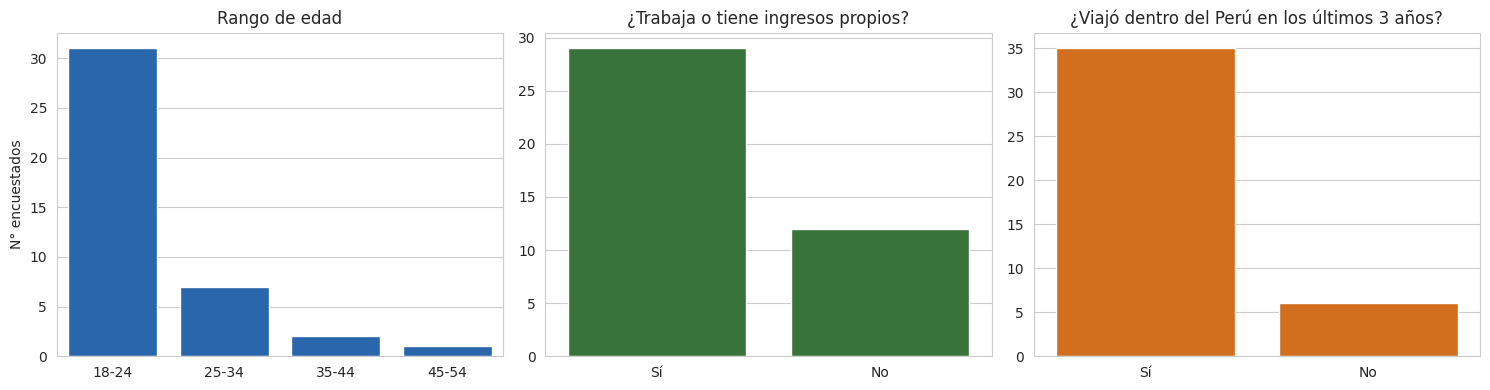

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

orden_edad = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
orden_edad_presente = [o for o in orden_edad if o in df_encuesta['edad'].unique()]

sns.countplot(data=df_encuesta, x='edad', order=orden_edad_presente, ax=axes[0], color='#1565c0')
axes[0].set_title('Rango de edad')
axes[0].set_xlabel(''); axes[0].set_ylabel('N° encuestados')

sns.countplot(data=df_encuesta, x='trabaja_actualmente', ax=axes[1], color='#2e7d32')
axes[1].set_title('¿Trabaja o tiene ingresos propios?')
axes[1].set_xlabel(''); axes[1].set_ylabel('')

sns.countplot(data=df_encuesta, x='viajo_ultimos_3_anios', ax=axes[2], color='#ef6c00')
axes[2].set_title('¿Viajó dentro del Perú en los últimos 3 años?')
axes[2].set_xlabel(''); axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# **Resultados**

La muestra está fuertemente concentrada en jóvenes de 18-24 años (31 de 41 encuestados, 75.6%), seguida por el grupo de 25-34 años (7, 17.1%); los rangos de 35-44 y 45-54 años representan en conjunto solo el 7.3% de la muestra.

La mayoría de los encuestados trabaja o tiene ingresos propios (29, 70.7%), y un alto porcentaje ya viajó dentro del Perú en los últimos 3 años (35, 85.4%).

Estos resultados confirman que la muestra corresponde principalmente a un público joven con experiencia previa de viaje doméstico, por lo que las conclusiones de la encuesta deben interpretarse como representativas de este segmento (viajero joven, ya familiarizado con el turismo interno) y no del universo general de turistas nacionales.

# **4.2 Gráficos de Disposición, Interés y Conocimiento Previo**

### **Objetivo**

Medir la disposición de los encuestados a elegir destinos menos conocidos, su interés en visitar regiones no tradicionales y su nivel de conocimiento previo sobre la oferta turística de las regiones menos visitadas, con el fin de dimensionar la demanda potencial para las estrategias de Kuska.

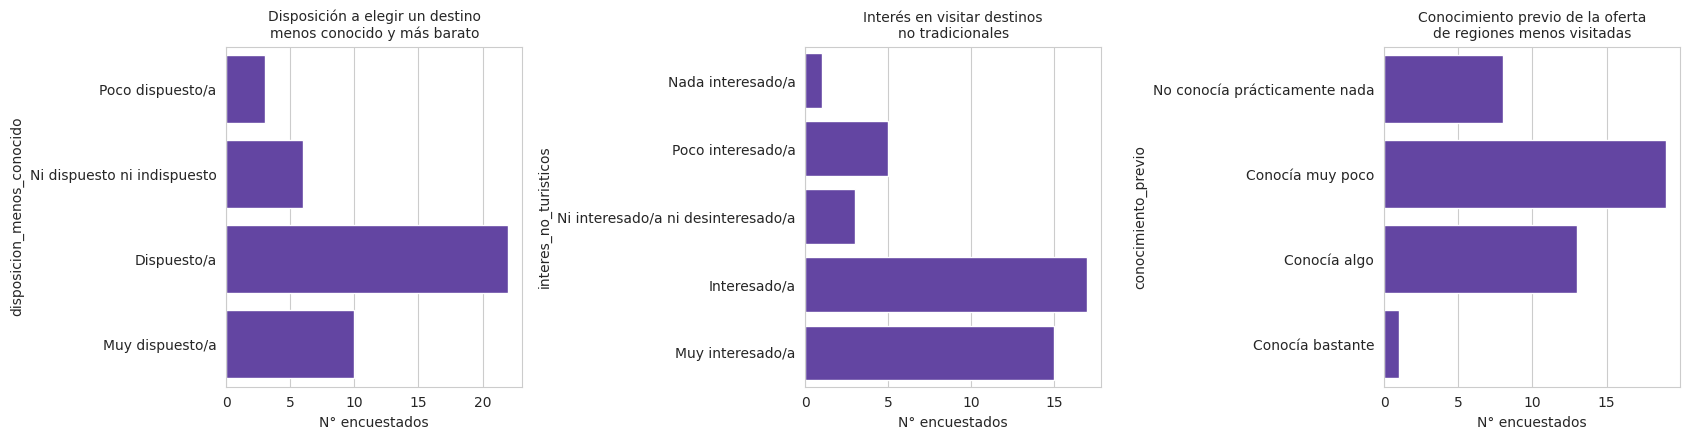

% dispuesto o muy dispuesto a elegir un destino menos conocido: 78.0%
% interesado o muy interesado en destinos no tradicionales: 78.0%
% que conocía muy poco o nada de la oferta menos visitada: 65.9%


In [ ]:
orden_disposicion = ['Poco dispuesto/a', 'Ni dispuesto ni indispuesto', 'Dispuesto/a', 'Muy dispuesto/a']
orden_interes = ['Nada interesado/a', 'Poco interesado/a', 'Ni interesado/a ni desinteresado/a', 'Interesado/a', 'Muy interesado/a']
orden_conocimiento = ['No conocía prácticamente nada', 'Conocía muy poco', 'Conocía algo', 'Conocía bastante']

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, col, orden, titulo in zip(
    axes,
    ['disposicion_menos_conocido', 'interes_no_turisticos', 'conocimiento_previo'],
    [orden_disposicion, orden_interes, orden_conocimiento],
    ['Disposición a elegir un destino\nmenos conocido y más barato',
     'Interés en visitar destinos\nno tradicionales',
     'Conocimiento previo de la oferta\nde regiones menos visitadas']
):
    counts = df_encuesta[col].value_counts().reindex(orden).fillna(0)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color='#5e35b1')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('N° encuestados')

plt.tight_layout()
plt.show()

pct_dispuesto = df_encuesta['disposicion_menos_conocido'].isin(['Dispuesto/a', 'Muy dispuesto/a']).mean() * 100
pct_interesado = df_encuesta['interes_no_turisticos'].isin(['Interesado/a', 'Muy interesado/a']).mean() * 100
pct_desconocimiento = df_encuesta['conocimiento_previo'].isin(['No conocía prácticamente nada', 'Conocía muy poco']).mean() * 100

print(f"% dispuesto o muy dispuesto a elegir un destino menos conocido: {pct_dispuesto:.1f}%")
print(f"% interesado o muy interesado en destinos no tradicionales: {pct_interesado:.1f}%")
print(f"% que conocía muy poco o nada de la oferta menos visitada: {pct_desconocimiento:.1f}%")

### **Resultados**

El 78.0% de los encuestados se declara dispuesto o muy dispuesto a elegir un destino menos conocido si el precio es más bajo, y ese mismo porcentaje (78.0%) se muestra interesado o muy interesado en visitar destinos no tradicionales. Esto indica una demanda potencial considerable hacia regiones subposicionadas, siempre que se comunique adecuadamente el precio y la propuesta de valor.

Sin embargo, el 65.9% de los encuestados conocía muy poco o nada de la oferta turística de las regiones menos visitadas antes de la encuesta. Esta brecha entre el interés declarado (78%) y el bajo conocimiento previo confirma que el principal obstáculo no es la falta de interés, sino la falta de visibilidad: existe una oportunidad clara para Kuska en campañas de difusión e información sobre estos destinos.

# **4.3 Gráfico de Regiones Consideradas para el Próximo Viaje**

### **Objetivo**

Identificar los departamentos que combinan interés potencial del público objetivo con una oferta turística subutilizada, con el fin de detectar oportunidades prioritarias para las estrategias de promoción de Kuska.


--- Regiones que los encuestados considerarían para su próximo viaje (checkbox + 'Otro') ---


,Menciones,% de encuestados
Amazonas,28,68.3
Cajamarca,27,65.9
Ayacucho,17,41.5
Áncash,10,24.4
Cusco,7,17.1
Arequipa,6,14.6
Huancavelica,2,4.9
Pasco,1,2.4
Tacna,1,2.4
Tumbes,1,2.4


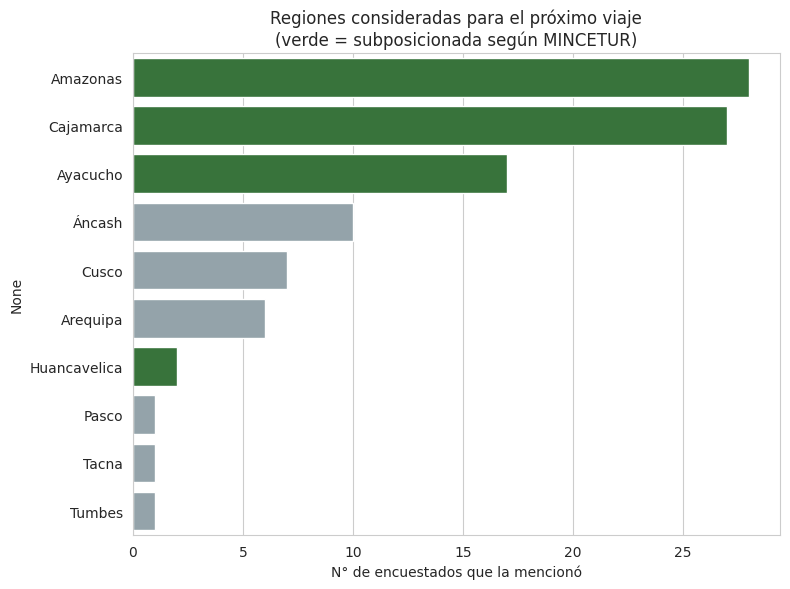

In [ ]:
def split_multi(series, fix_y_conjunction=False):
    """Convierte una columna de respuesta múltiple (separada por comas) en listas de opciones limpias.
    fix_y_conjunction=True corrige el caso en que Google Forms concatena el último ítem con ' y '
    (ej. 'Cusco, Oxapampa y Arequipa'). No usar en columnas donde 'y' puede ser parte del texto
    de una opción (ej. 'Calidad de hoteles y hospedajes')."""
    def _clean(x):
        if pd.isna(x):
            return []
        x = str(x)
        if fix_y_conjunction:
            x = re.sub(r'\s+y\s+', ', ', x)
        return [p.strip().title() for p in x.split(',') if p.strip()]
    return series.apply(_clean)

regiones_listas = split_multi(df_encuesta['regiones_interes'], fix_y_conjunction=True)
region_counts = pd.Series(Counter([r for lst in regiones_listas for r in lst])).sort_values(ascending=False)
region_pct = (region_counts / len(df_encuesta) * 100).round(1)

df_regiones = pd.DataFrame({'Menciones': region_counts, '% de encuestados': region_pct})
print("\n--- Regiones que los encuestados considerarían para su próximo viaje (checkbox + 'Otro') ---")
display(df_regiones)

under_positioned_regions = offer_demand_profile_sorted.head(5)['departamento'].tolist()
region_counts_norm = region_counts.copy()
region_counts_norm.index = region_counts_norm.index.str.upper()

fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#2e7d32' if r in under_positioned_regions else '#90a4ae' for r in region_counts_norm.index]
sns.barplot(x=region_counts.values, y=region_counts.index, hue=region_counts.index,
            palette=colores, legend=False, ax=ax)
ax.set_title('Regiones consideradas para el próximo viaje\n(verde = subposicionada según MINCETUR)')
ax.set_xlabel('N° de encuestados que la mencionó')
plt.tight_layout()
plt.show()

### **Resultados**

La triangulación entre las menciones de la encuesta y la clasificación de subposicionamiento de MINCETUR permitió identificar a Amazonas, Cajamarca y Ayacucho como los departamentos que concentran simultáneamente alto interés potencial y una oferta turística subutilizada.

Estas regiones registraron 28, 27 y 17 menciones, respectivamente, y fueron clasificadas como subposicionadas en el análisis de ocupación hotelera. La coincidencia entre ambos indicadores evidencia una demanda potencial que aún no se refleja plenamente en la utilización de la oferta disponible, por lo que representan oportunidades para transformar el interés declarado en visitas efectivas.

# **4.4 Gráficos de Factores de Elección y Razones para No Visitar**

### **Objetivo**

Identificar los principales factores que influyen en la elección de un destino turístico y las barreras que pueden limitar la visita, con el fin de orientar las estrategias de promoción hacia las necesidades y preocupaciones del público objetivo.

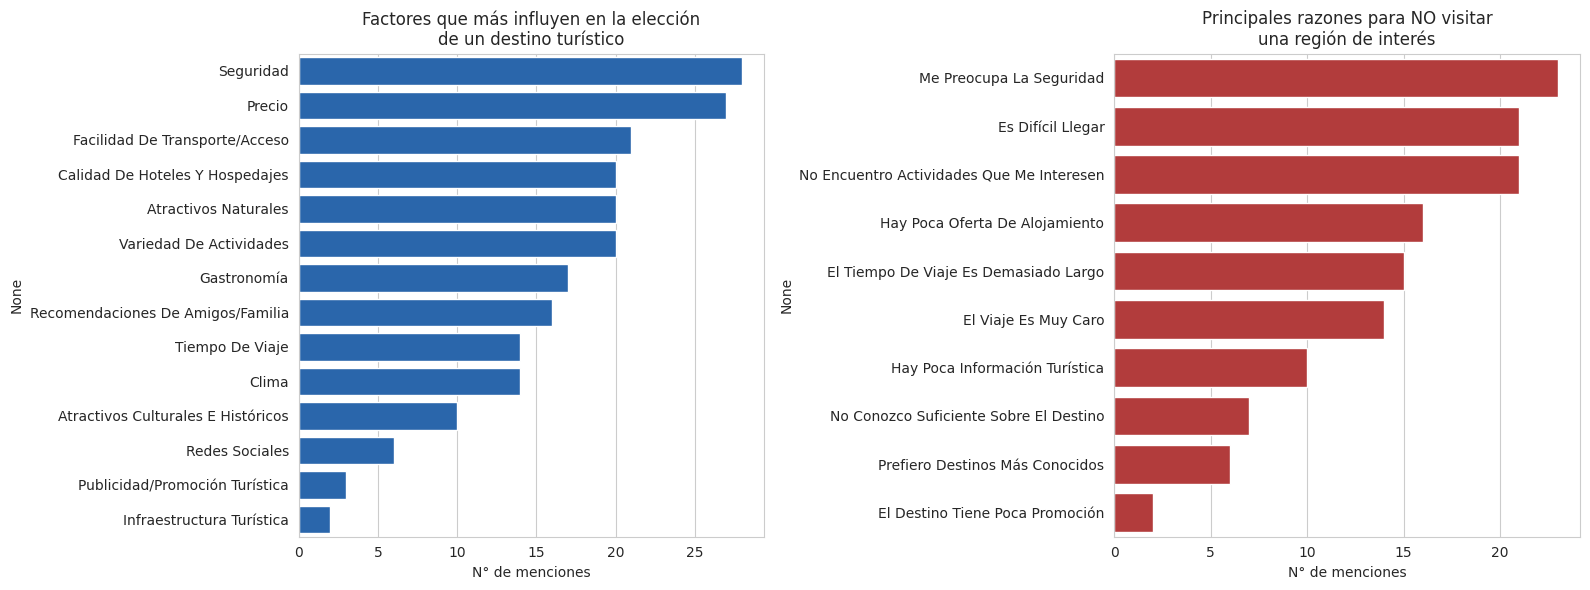

In [ ]:
factores_listas = split_multi(df_encuesta['factores_eleccion'])
factores_counts = pd.Series(Counter([r for lst in factores_listas for r in lst])).sort_values(ascending=False)

razones_listas = split_multi(df_encuesta['razones_no_visitar'])
razones_counts = pd.Series(Counter([r for lst in razones_listas for r in lst])).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=factores_counts.values, y=factores_counts.index, ax=axes[0], color='#1565c0')
axes[0].set_title('Factores que más influyen en la elección\nde un destino turístico')
axes[0].set_xlabel('N° de menciones')

sns.barplot(x=razones_counts.values, y=razones_counts.index, ax=axes[1], color='#c62828')
axes[1].set_title('Principales razones para NO visitar\nuna región de interés')
axes[1].set_xlabel('N° de menciones')

plt.tight_layout()
plt.show()

### **Resultados**

Los factores que más influyen en la elección de un destino son la seguridad (28 menciones), el precio (27), la facilidad de transporte y acceso (21), la calidad de hoteles y hospedajes (20), los atractivos naturales (20) y la variedad de actividades (20).

Por otro lado, las principales barreras para visitar una región de interés son la preocupación por la seguridad (23 menciones), la dificultad para llegar (21) y la falta de actividades de interés (21). También destacan la poca oferta de alojamiento (16) y el tiempo de viaje elevado (15).

En conjunto, los resultados muestran que seguridad, precio y accesibilidad son elementos centrales tanto en la elección como en las posibles barreras de viaje. Para los destinos subposicionados, estos hallazgos permiten orientar la comunicación hacia la reducción de dichas barreras y una mejor visibilización de su oferta turística.

# **4.5 Gráficos de Importancia del Alojamiento y Gasto Dispuesto**

### **Objetivo**

Analizar la importancia que el público objetivo atribuye a la oferta de alojamiento y su disposición de gasto en viajes nacionales de 3-4 días, con el fin de identificar condiciones de oferta y rangos de presupuesto relevantes para la promoción de destinos turísticos.

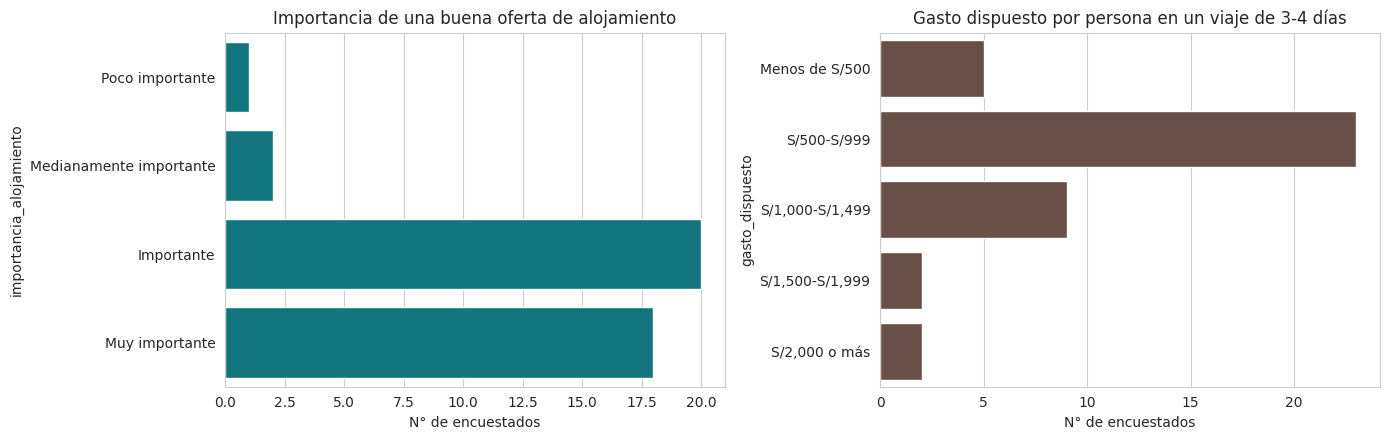


Gasto dispuesto por rango de edad


gasto_dispuesto,Menos de S/500,S/500-S/999,"S/1,000-S/1,499","S/1,500-S/1,999","S/2,000 o más"
edad,,,,,
18-24,3,18,6,2,2
25-34,1,4,2,0,0
35-44,1,1,0,0,0
45-54,0,0,1,0,0


In [ ]:
orden_alojamiento = ['Poco importante', 'Medianamente importante', 'Importante', 'Muy importante']
orden_gasto = ['Menos de S/500', 'S/500-S/999', 'S/1,000-S/1,499', 'S/1,500-S/1,999', 'S/2,000 o más']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

counts_aloj = df_encuesta['importancia_alojamiento'].value_counts().reindex(orden_alojamiento).fillna(0)
sns.barplot(x=counts_aloj.values, y=counts_aloj.index, ax=axes[0], color='#00838f')
axes[0].set_title('Importancia de una buena oferta de alojamiento')
axes[0].set_xlabel('N° de encuestados')

counts_gasto = df_encuesta['gasto_dispuesto'].value_counts().reindex(orden_gasto).fillna(0)
sns.barplot(x=counts_gasto.values, y=counts_gasto.index, ax=axes[1], color='#6d4c41')
axes[1].set_title('Gasto dispuesto por persona en un viaje de 3-4 días')
axes[1].set_xlabel('N° de encuestados')

plt.tight_layout()
plt.show()

print("\nGasto dispuesto por rango de edad")
display(pd.crosstab(df_encuesta['edad'], df_encuesta['gasto_dispuesto'])[
    [c for c in orden_gasto if c in df_encuesta['gasto_dispuesto'].unique()]
])

### **Resultados**

La oferta de alojamiento tiene una alta importancia para los encuestados: 20 personas la consideran importante y 18 muy importante (38 de 41, 92.7% en conjunto), frente a solo 3 que la consideran poco o medianamente importante. En cuanto al gasto, el rango de S/500-S/999 es el más frecuente (23 encuestados), seguido de S/1,000-S/1,499 (9 encuestados).

El análisis por edad muestra que, dentro del grupo de 18-24 años (31 encuestados), 18 se ubican en S/500-999 y 8 superan los S/1,000 (6 en S/1,000-1,499, 2 en S/1,500-1,999 y 2 en S/2,000 o más). En el grupo de 25-34 años (7 encuestados), 4 se ubican en S/500-999 y 2 superan los S/1,000 (ambos en S/1,000-1,499), sin encuestados en los rangos más altos. Proporcionalmente, ambos grupos concentran su gasto en S/500-999; con esta muestra no hay evidencia suficiente para afirmar que el grupo de 25-34 años tenga mayor disposición hacia rangos de gasto superiores.

En conjunto, los resultados resaltan la importancia de ofrecer alojamiento de calidad a precios acordes con el presupuesto del público objetivo, concentrado mayormente entre S/500 y S/1,499 por persona.

# **4.6 Gráfico de Matriz de Triangulación: Demanda Real (MINCETUR) vs. Demanda Potencial (Encuesta)**

### **Objetivo**

Construir una matriz de triangulación que relacione la demanda potencial, medida por el interés de los encuestados, con la demanda real, medida por la TNOH promedio, para clasificar los departamentos según su situación turística.

In [ ]:
import unicodedata

def normalize_name(s):
    s = str(s).strip().upper()
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

df_real = offer_demand_profile_sorted[[
    'departamento', '% TNOH (Prom. Mensual)',
    'Arribos Totales (Prom. Mensual)', 'Permanencia (Prom. Mensual, Días)'
]].copy()
df_real['key'] = df_real['departamento'].apply(normalize_name)

df_potencial = df_regiones.reset_index().rename(columns={'index': 'region'})
df_potencial['key'] = df_potencial['region'].apply(normalize_name)

# inner: solo se conservan las regiones que aparecen en MINCETUR Y en la encuesta
df_triangulacion = df_real.merge(
    df_potencial[['key', 'Menciones', '% de encuestados']], on='key', how='inner'
).drop(columns='key')

df_triangulacion = df_triangulacion.rename(columns={
    '% TNOH (Prom. Mensual)': 'TNOH_real',
    '% de encuestados': 'Interes_potencial'
})

print(f"Regiones cruzadas (presentes en ambas fuentes): {len(df_triangulacion)}")
display(df_triangulacion.sort_values('Interes_potencial', ascending=False))

Regiones cruzadas (presentes en ambas fuentes): 10


,departamento,TNOH_real,Arribos Totales (Prom. Mensual),"Permanencia (Prom. Mensual, Días)",Menciones,Interes_potencial
2,AMAZONAS,19.727690,7779.319149,1.109301,28,68.3
0,CAJAMARCA,17.004788,13013.704359,1.259735,27,65.9
1,AYACUCHO,17.284218,8256.480253,1.634092,17,41.5
4,ANCASH,20.542968,18453.319481,1.516844,10,24.4
9,CUSCO,29.552454,37997.987082,1.815449,7,17.1
7,AREQUIPA,27.426093,18006.641860,1.868219,6,14.6
3,HUANCAVELICA,19.992443,4024.701561,1.313811,2,4.9
5,TACNA,21.197096,7834.747536,1.856126,1,2.4
6,PASCO,21.410923,6138.297315,1.343163,1,2.4
8,TUMBES,29.420061,5315.781868,2.267880,1,2.4


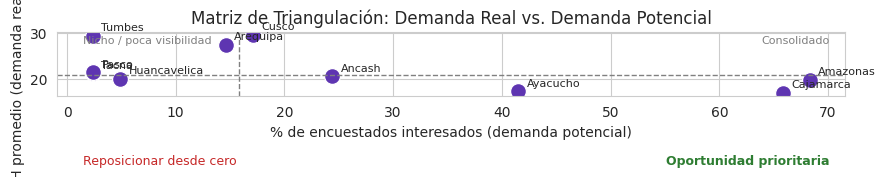

In [ ]:
med_tnoh = df_triangulacion['TNOH_real'].median()
med_interes = df_triangulacion['Interes_potencial'].median()

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=df_triangulacion, x='Interes_potencial', y='TNOH_real', s=130, ax=ax, color='#5e35b1')

for _, row in df_triangulacion.iterrows():
    ax.annotate(row['departamento'].title(), (row['Interes_potencial'], row['TNOH_real']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axvline(med_interes, color='gray', linestyle='--', linewidth=1)
ax.axhline(med_tnoh, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('% de encuestados interesados (demanda potencial)')
ax.set_ylabel('% TNOH promedio (demanda real / ocupación)')
ax.set_title('Matriz de Triangulación: Demanda Real vs. Demanda Potencial')

xmax, ymax = ax.get_xlim()[1], ax.get_ylim()[1]
ax.text(xmax*0.02, ymax*0.98, 'Nicho / poca visibilidad', va='top', fontsize=8, color='gray')
ax.text(xmax*0.98, ymax*0.98, 'Consolidado', va='top', ha='right', fontsize=8, color='gray')
ax.text(xmax*0.98, ymax*0.05, 'Oportunidad prioritaria', ha='right', fontsize=9, color='#2e7d32', fontweight='bold')
ax.text(xmax*0.02, ymax*0.05, 'Reposicionar desde cero', fontsize=9, color='#c62828')

plt.tight_layout()
plt.show()

### **Resultados**

El gráfico utiliza las medianas del interés potencial (15.85%) y de la TNOH (20.87%) como puntos de corte, dividiendo los departamentos en cuatro categorías: Consolidado, Nicho/Poca Visibilidad, Oportunidad Prioritaria y Reposicionar desde Cero.

En el cuadrante de **Oportunidad Prioritaria** (baja TNOH real + alto interés declarado) se ubican cuatro departamentos: **Amazonas** (19.7% TNOH, 68.3% interés), **Cajamarca** (17.0% TNOH, 65.9% interés), **Ayacucho** (17.3% TNOH, 41.5% interés) y **Ancash** (20.5% TNOH, 24.4% interés). Estos representan la mayor oportunidad para Kuska: alta demanda potencial que hoy no se traduce en ocupación real.

Huancavelica, si bien también tiene una TNOH baja (20.0%), registra un interés declarado muy bajo (4.9%, por debajo de la mediana), por lo que se ubica en el cuadrante de "Reposicionar desde cero": su problema no es solo de visibilidad de la oferta, sino de interés genuino del público, lo que exige una estrategia distinta (generar demanda desde cero) en lugar de solo promoción.

In [ ]:
oportunidad_prioritaria = df_triangulacion[
    (df_triangulacion['TNOH_real'] <= med_tnoh) &
    (df_triangulacion['Interes_potencial'] >= med_interes)
].sort_values('Interes_potencial', ascending=False)

print("Regiones de OPORTUNIDAD PRIORITARIA (baja ocupación real + alto interés declarado):")
display(oportunidad_prioritaria[['departamento', 'TNOH_real', 'Interes_potencial']])

Regiones de OPORTUNIDAD PRIORITARIA (baja ocupación real + alto interés declarado):


,departamento,TNOH_real,Interes_potencial
2,AMAZONAS,19.727690,68.3
0,CAJAMARCA,17.004788,65.9
1,AYACUCHO,17.284218,41.5
4,ANCASH,20.542968,24.4


# **Análisis de Outliers: Boxplot de Tasa Neta de Ocupación Hotelera (TNOH)**

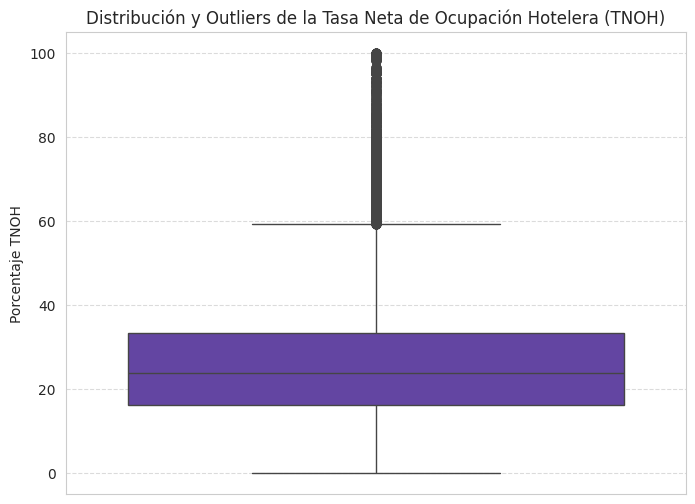

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(y=df_mincetur['porcentaje_tnoh'], color='#5e35b1', ax=ax)
ax.set_title('Distribución y Outliers de la Tasa Neta de Ocupación Hotelera (TNOH)')
ax.set_ylabel('Porcentaje TNOH')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretación de los Outliers:**

El boxplot del `porcentaje_tnoh` muestra que la mediana de ocupación hotelera se ubica alrededor del 24%, con el 50% central de los datos (Q1-Q3) entre aproximadamente 16% y 33%. Esto confirma que la mayoría de los registros mensuales de establecimientos operan con una ocupación baja a moderada.

*   **No hay outliers en el extremo bajo:** El bigote inferior se extiende hasta 0% sin ningún punto marcado como atípico. Esto significa que, aunque existen registros con ocupación nula o cercana a 0%, estos valores están dentro del rango esperado (no se desvían lo suficiente del Q1 según el criterio de 1.5×IQR) y probablemente reflejan estacionalidad baja real, más que errores de datos.
*   **Los outliers se concentran en el extremo alto:** Se observa una densa acumulación de puntos atípicos por encima del bigote superior (~59%), extendiéndose hasta 100%. Esto indica que un número considerable de establecimientos u observaciones mensuales opera con una ocupación excepcionalmente alta respecto al comportamiento típico del sector, posiblemente en temporadas de alta demanda, destinos consolidados (Cusco, Arequipa) o meses/regiones puntuales de gran afluencia.

**Implicaciones para Kuska:**
A diferencia de lo que podría esperarse, los valores atípicos de esta distribución no señalan "ventanas de oportunidad" por ocupación nula, sino picos de demanda ya consolidada en ciertos destinos y períodos. Para Kuska, esto refuerza la estrategia de enfocar la promoción en las regiones con ocupación consistentemente baja (identificadas en el Bloque 3: Cajamarca, Ayacucho, Amazonas, Huancavelica), en lugar de interpretar los outliers bajos del boxplot general como esas oportunidades, ya que dichos outliers bajos prácticamente no existen en el conjunto de datos.